<div style="display:flex;align-items:center;justify-content:center;flex-direction:column;padding:18px 0;">
<h1 style="font-family: 'Segoe UI', Roboto, Arial; font-size:48px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">
DBSCAN CLUSTERING ASSIGNMENT
</h1>
<p style="margin:8px 0 0; color:#334155; font-size:16px;">A concise workbook covering how to build DBSCAN clustering models, evaluate their performance, and interpret their coefficients to derive meaningful insights.</p>
</div>

---

<div style="display:flex;gap:12px;flex-wrap:wrap;align-items:center;">
<span style="background:#eef2ff;color:#3730a3;padding:6px 10px;border-radius:8px;font-weight:600;">📘 Basics</span>
<span style="background:#ecfdf5;color:#065f46;padding:6px 10px;border-radius:8px;font-weight:600;">⚙️ Examples</span>
<span style="background:#fff7ed;color:#92400e;padding:6px 10px;border-radius:8px;font-weight:600;">🔁 Exercises</span>
</div>


<details><summary><strong>Notebook info</strong></summary>

- **Author:** Sandipan Roy
- **Assignment Date:** 2026-05-11
- **Assignment Given By:** Karkavel Raja
- **Sections:** Importing Libraries · Data Loading · Data Preprocessing & Transformation Operations · Exploratory Data Analysis (EDA) · Fine-tuning and Optimization · Model Building · Model Evaluation · Model Optimization and Insights

</details>

---



<div style="display:flex;align-items:center;justify-content:center;flex-direction:column;padding:18px 0;">
<h2 style="font-family: 'Segoe UI', Roboto, Arial; font-size:38px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">Problem Statement:</h2>

---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">The objective of this assignment is to utilize the DBSCAN (Density-Based Spatial Clustering of Applications with Noise) algorithm to analyze the provided dataset, extracting meaningful insights from its underlying structures. By exploring the datasets and employing DBSCAN techniques, students are expected to categorize the data into distinct clusters. This assignment emphasizes parameter tuning for optimal clustering results and requires interpretation of the clustering outcomes to derive valuable insights.</p>
</div>

---



<div style="display:flex;align-items:center;justify-content:center;flex-direction:column;padding:18px 0;">
<h2 style="font-family: 'Segoe UI', Roboto, Arial; font-size:38px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">Dataset for the Assignment:</h2>

---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">


-   [Clustering Penguins Species | Kaggle](https://www.kaggle.com/datasets/youssefaboelwafa/clustering-penguins-species)
-   [Customer Personality Analysis | Kaggle](https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis)
-   [Credit Card Customer Data | Kaggle](https://www.kaggle.com/datasets/aryashah2k/credit-card-customer-data)


</p>
</div>

---


<div style="display:flex;align-items:center;justify-content:center;flex-direction:column;padding:18px 0;">
<h2 style="font-family: 'Segoe UI', Roboto, Arial; font-size:38px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">Business Objective:</h2>

---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">

- [Customer Personality Analysis | Kaggle](https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis) :- Analysis of company's ideal customers.

Customer Personality Analysis is a detailed analysis of a company’s ideal customers. It helps a business to better understand its customers and makes it easier for them to modify products according to the specific needs, behaviors and concerns of different types of customers.

The goal is to develop a customer segmentation to define marketing strategy using DBSCAN Clustering algorithm, so that business can modify its product based on its target customers from different types of customer segments.
</p>
</div>

---

<h3 style="font-family: 'Segoe UI', Roboto, Arial; font-size:28px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">1. Setup and Data Preparation:</h3>


---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Install the required libraries if not present.</u></li>
</ul>
</p>

---


In [1]:
!pip install scikit-learn
## kneelocator
!pip install kneed
# yellowbrick
!pip install yellowbrick


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Import all the required libraries and orchastrate control over the behaviour and display settings of pandas.</u></li>
</ul>
</p>

---


In [2]:
# Importing warning to disable runtime warnings
import warnings
# Warnings will appear only once
warnings.filterwarnings("ignore")

#=================================================================================

from datetime import datetime
# Importing Numpy Library and aliasing it's name as np
import numpy as np
# Importing Pandas Library and aliasing it's name as pd
import pandas as pd
# Importing the Pyplot Interface from within the Matplotlib Library and aliasing it as plt
import matplotlib.pyplot as plt
# The above line of code can also be written as-
#    from matplotlib import pyplot as plt

# Importing Seaborn Library and aliasing it's name as sns
import seaborn as sns

# Importing the Plotly Express Interface from within the Plotly Library and aliasing it as px
import plotly.express as px

import pickle
#=================================================================================
# Importing the StandardScaler and RobustScaler Classes from the preprocessing module of the Scikit-Learn Library
from sklearn.preprocessing import RobustScaler, StandardScaler, LabelEncoder
# Importing the train_test_split function from the model_selection module of the Scikit-Learn Library
from sklearn.model_selection import train_test_split
# Importing the KElbowVisualizer Class from the cluster module of the Yellowbrick Library
from yellowbrick.cluster import KElbowVisualizer
# Importing the silhouette_score function from the metrics module of the Scikit-Learn Library
from sklearn.metrics import silhouette_score
# Importing the DBSCAN Class from the cluster module of the Scikit-Learn Library
from sklearn.cluster import DBSCAN
##  Applying PCA Algorithms
from sklearn.decomposition import PCA
from kneed import KneeLocator
# Importing the KNNImputer Class from the impute module of the Scikit-Learn Library
from sklearn.impute import KNNImputer
# Importing the NearestNeighbors Class from the neighbors module of the Scikit-Learn Library
from sklearn.neighbors import NearestNeighbors

#=================================================================================

# Unfolding hidden features if the cardinality is high
pd.set_option('display.max_columns', None)
# Unfolding the max feature width for better clearity
pd.set_option('display.max_colwidth', None)
# Unfolding hidden data points if the cardinality is high
pd.set_option('display.max_rows', None)
# Removing restriction over chained assignments operations
pd.set_option('mode.chained_assignment', None)
# To suppress scientific notation over exponential values
pd.set_option('display.float_format', lambda x: '%.5f' % x)

%matplotlib inline

---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Acquire data from datasource and bring it in-memory.</u></li>
</ul>
</p>

---


In [3]:
def acquire_data(url, sourceType="csv", verbose=False):
    """
    This function acquires data from the given URL and returns a DataFrame.

    Parameters:
    url (str): The URL from which to acquire the data.
    sourceType (str): The type of the data source (default is "csv").
    verbose (bool): If True, prints the shape of the DataFrame and its columns.

    Returns:
    pd.DataFrame: The acquired data as a DataFrame.
    """

    if sourceType.lower() != "csv":
        raise ValueError("Currently, only 'csv' source type is supported.")

    # Reading the CSV file from the provided URL
    df = pd.read_csv(url, sep="\t")

    # If verbose is True, print the shape of the DataFrame and its columns
    if verbose:
        print(f"DataFrame Shape: {df.shape}, i.e., {df.shape[0]} rows and {df.shape[1]} columns.")
        print(f"DataFrame Columns: {df.columns.tolist()}")

    return df

In [4]:
url = "https://raw.githubusercontent.com/Sandipan-Roy/sr/refs/heads/Dev/ML/Unsupervised/DBSCAN/data/raw/marketing_campaign.csv"
data = acquire_data(url, verbose=True)

DataFrame Shape: (2240, 29), i.e., 2240 rows and 29 columns.
DataFrame Columns: ['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Analyze the aquired data and perform pre-profiling.</u></li>
</ul>
</p>

---


In [5]:
def analyze_data(df):
    """
    This function performs basic analysis on the given DataFrame and prints the results.

    Parameters:
    df (pd.DataFrame): The DataFrame to analyze.

    Returns:
    __dict__: A dictionary containing the results of the numerical columns and categorical columns list.
    """
    df_col_counts = len(data.columns)
    col_break_points = df_col_counts // 5 + 1

    i,p = 0, 0
    for cc in range(1, 6):
        i += col_break_points
        if i > df_col_counts:
            i = df_col_counts
        # Displaying the first 5 rows of the DataFrame for the current set of columns
        print(f"First 5 rows of the from {p} to {i-1 if i<df_col_counts else i} columns:")
        print(df.iloc[:, p:i].head())
        p = i

    # Displaying the shape of the DataFrame
    print(f"\nShape of the DataFrame: {df.shape}")

    # Displaying the data types of each column
    print("\nData types of each column:")
    print(df.dtypes)

    print("-" * 50)
    #Displaying information about the DataFrame
    print("\nInformation about the DataFrame:")
    print(df.info())

    print("-" * 50)
    # Displaying the memory usage of the DataFrame
    print(f"\nMemory usage of the DataFrame: {(df.memory_usage(deep=True)).sum() / 1024:.2f} KB")  # Converting bytes to kilobytes
    print(((df.memory_usage(deep=True)) / 1024).round(2))  # Converting bytes to kilobytes

    # Listing numerical columns
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    # Listing categorical columns
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    print("\nWe have {} numerical features: {}".format(len(numerical_cols), numerical_cols))
    print("We have {} categorical features: {}".format(len(categorical_cols), categorical_cols))

    print("-" * 50)
    print("\nNumber of duplicated rows: {} ({}% of total rows)".format(
                    df.duplicated().sum(),
                    round(df.duplicated().sum() / df.shape[0] * 100, 2)
                    ))

    if len(numerical_cols) > 0:
      # Displaying summary statistics for numerical columns
      print("\nSummary statistics for numerical columns:")
      print(df.describe())

    print("-" * 50)
    if len(categorical_cols) > 0:
      # Displaying summary statistics for categorical columns
      print("\nSummary statistics for categorical columns:")
      print(df.describe(include=['object']))


    # Returning the list of numerical and categorical columns
    return {
        "numerical_columns": numerical_cols if len(numerical_cols) > 0 else None,
        "categorical_columns": categorical_cols if len(categorical_cols) > 0 else None
    }


In [6]:
dictColumns = analyze_data(data)
numerical_columns = dictColumns["numerical_columns"]
categorical_columns = dictColumns["categorical_columns"]

First 5 rows of the from 0 to 5 columns:
     ID  Year_Birth   Education Marital_Status      Income  Kidhome
0  5524        1957  Graduation         Single 58138.00000        0
1  2174        1954  Graduation         Single 46344.00000        1
2  4141        1965  Graduation       Together 71613.00000        0
3  6182        1984  Graduation       Together 26646.00000        1
4  5324        1981         PhD        Married 58293.00000        1
First 5 rows of the from 6 to 11 columns:
   Teenhome Dt_Customer  Recency  MntWines  MntFruits  MntMeatProducts
0         0  04-09-2012       58       635         88              546
1         1  08-03-2014       38        11          1                6
2         0  21-08-2013       26       426         49              127
3         0  10-02-2014       26        11          4               20
4         0  19-01-2014       94       173         43              118
First 5 rows of the from 12 to 17 columns:
   MntFishProducts  MntSweetProducts  Mn

---
<a name = Section4></a>
### Data Acquisition Observations
---
The dataset consists of the data of customers that have similar characteristics with specific needs, behaviors and concerns for the purpose to modify its product based on its target customers from different types of customer segments.


| Records | Features | Dataset Size |
| :-- | :-- | :-- |
| 2240 | 29 | 507.6+ KB |


| ID | Feature Name | Description of the feature | Data Type |
| :-- | :--| :--| :--|
|01| **ID**   | Customer’s unique identifier                                | int64 |
|02| **Year_Birth**   | Customer's birth year                                | int64 |
|03| **Education**   | Education Qualification of customer                                | object |
|04| **Marital_Status**   | Marital Status of customer                                | object |
|05| **Income**   | Customer's yearly household income                                | float64 |
|06| **Kidhome**   | Number of children in customer's household                                | int64 |
|07| **Teenhome**   | Number of teenagers in customer's household                                | int64 |
|08| **Dt_Customer**   | Date of customer's enrollment with the company                                | object |
|09| **Recency**   | Number of days since customer's last purchase                                | int64 |
|10| **MntWines**   | Amount spent on wine                                | int64 |
|11| **MntFruits**   | Amount spent on fruits                                | int64 |
|12| **MntMeatProducts**   | Amount spent on meat products                                | int64 |
|13| **MntFishProducts**   | Amount spent on fish products                                | int64 |
|14| **MntSweetProducts**   | Amount spent on sweet products                                | int64 |
|15| **MntGoldProds**   | Amount spent on gold products                                | int64 |
|16| **NumDealsPurchases**   | Number of purchases made with a discount                                | int64 |
|17| **NumWebPurchases**   | Number of purchases made through the company’s web site                                | int64 |
|18| **NumCatalogPurchases**   | Number of purchases made using a catalogue                                | int64 |
|19| **NumStorePurchases**   | Number of purchases made directly in stores                                | int64 |
|20| **NumWebVisitsMonth**   | Number of visits in the company's website                                | int64 |
|21| **AcceptedCmp3**   | 1 if customer accepted the offer in 3rd campaign, otherwise 0                                | int64 |
|22| **AcceptedCmp4**   | 1 if customer accepted the offer in 4th campaign, otherwise 0                                | int64 |
|23| **AcceptedCmp5**   | 1 if customer accepted the offer in 5th campaign, otherwise 0                                | int64 |
|24| **AcceptedCmp1**   | 1 if customer accepted the offer in 1st campaign, otherwise 0                               | int64 |
|25| **AcceptedCmp2**   | 1 if customer accepted the offer in 2nd campaign, otherwise 0                                | int64 |
|26| **Complain**   | 1 if customer complained in last 2 years, else 0                                | int64 |
|27| **Z_CostContact**   | Total cost of the campaigns                                | int64 |
|28| **Z_Revenue**   | Revenue earned from the campaign                                | int64 |
|29| **Response**   | 1 if customer accepted the offer in the last campaign, otherwise 0                                | int64 |


---

- Shape of the DataFrame: (2240, 29)
- Data types of all are correct, except 'Dt_Customer' (which is of type date but represented as object)
- There are no duplicate records.
- Except 'Education', 'Marital_Status' and 'Dt_Customer', all columns are of type numeric
- Memory usage by DataFrame: 830.49 KB


<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Uni-variate Analysis.</u></li>
</ul>
</p>

---

In [7]:
total_datapoints = data.shape[0]
print(f"Total number of data points: {total_datapoints}")

Total number of data points: 2240


In [8]:
def plot_univariate_distribution(df, column, plot_type="histogram", plot_width=6, plot_height=4, bins=None):
    """
    This function plots the univariate distribution of a specified column in the DataFrame.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.
    column (str): The name of the column to plot.
    plot_type (str): The type of plot to create ("histogram" or "boxplot" or "countplot").
    plot_width (int): The width of the plot.
    plot_height (int): The height of the plot.
    bins (int): The number of bins for the histogram.

    Returns:
    None
    """

    fig = plt.figure(figsize=(plot_width, plot_height))

    if plot_type != "boxplot":
        if plot_type == "histogram":
            if bins is not None:
                ax = sns.histplot(df[column], kde=True, color='blue', bins=bins)
            else:
                ax = sns.histplot(df[column], kde=True, color='blue')
            plt.ylabel('Frequency')
        elif plot_type == "countplot":
            ax = sns.countplot(x=df[column], palette='magma')
            plt.ylabel('Count')
        else:
            raise ValueError("Invalid plot type. Use 'histogram' or 'boxplot' or 'countplot'.")

        for p in ax.patches:
            percentage = '{:.2f}%'.format(100 * p.get_height() / total_datapoints)
            x = p.get_x() + p.get_width()/5
            y = p.get_y() + p.get_height()
            ax.annotate(percentage, (x, y))

    else:
        ax = sns.boxplot(x=df[column], palette='magma')


    plt.title(f'{plot_type.capitalize()} of {column.capitalize()}')
    plt.xlabel(column.capitalize())
    plt.show()

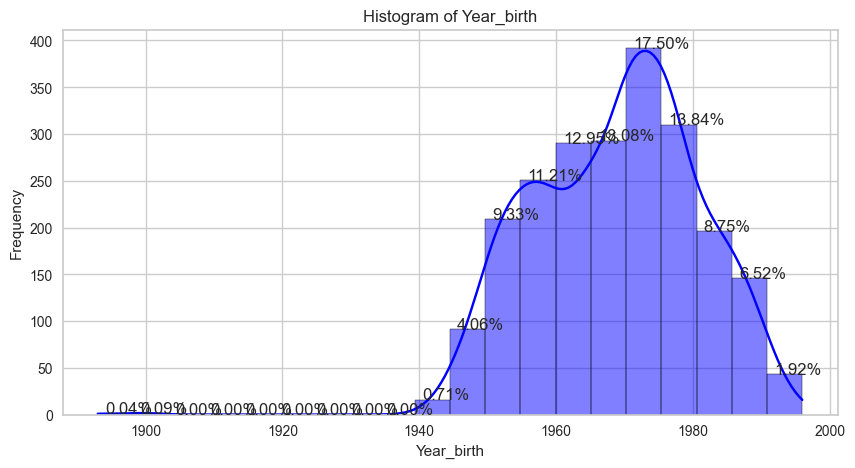

In [9]:
plot_univariate_distribution(data, column="Year_Birth", plot_type="histogram", plot_width=10, plot_height=5, bins=20)

---
<a name = Section2></a>
#### Insights:

- This feature represents Customer's birth year
- Approx 50% customer has born in between 1960-1980
- Approx 25% customer are there who has born before 1960


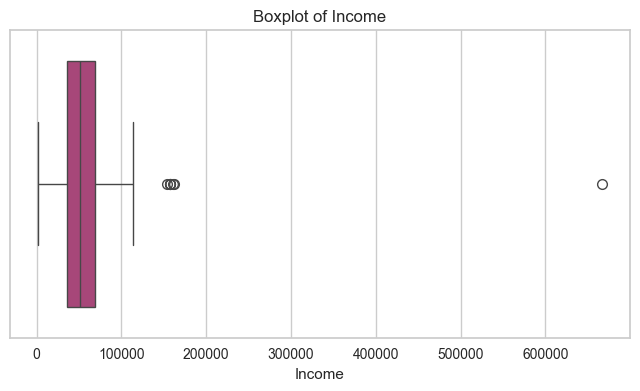

In [10]:
plot_univariate_distribution(data, column="Income", plot_type="boxplot", plot_width=8)

---
<a name = Section2></a>
#### Insights:

- Customer's yearly household income
- 25% cusomer's income lies below 35000
- 50% customer's income lies below 51000
- 75% coustomers income is below 69000
- There are some customers relatively high income making the data right-skewed

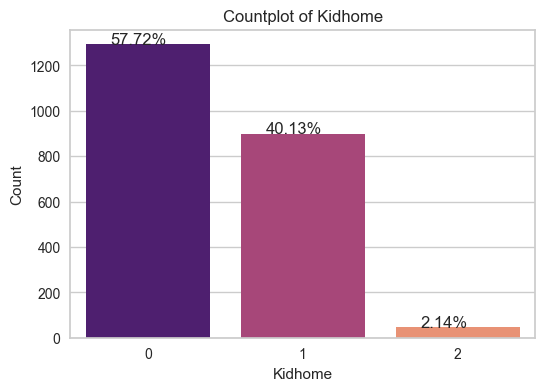

In [11]:
plot_univariate_distribution(data, column="Kidhome", plot_type="countplot")

---
<a name = Section2></a>
#### Insights:

- Number of children in customer's household 
- Approx 58% customer's don't hane any children in their household
- Approx 40% customer's have 1 children in their household
- Approx 2% customer's gave 2 children

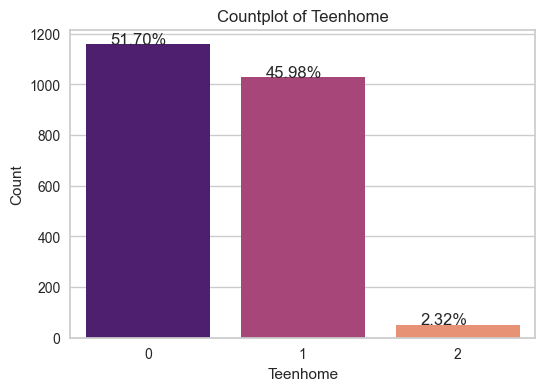

In [12]:
plot_univariate_distribution(data, column="Teenhome", plot_type="countplot")

---
<a name = Section2></a>
#### Insights:

- Number of teenagers in customer's household
- Approx 51% customer's don't have any teenagers in their household
- Approx 46% customer has only 1 teenager in their household
- Approx 2% customer has 2 teenagers in their household

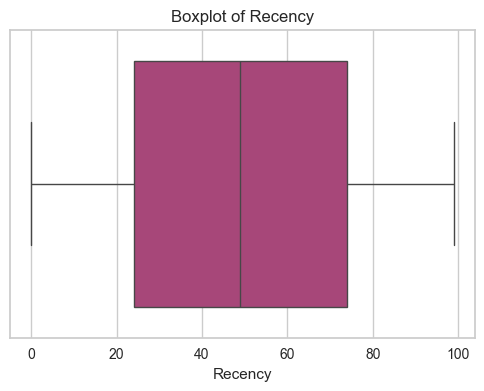

In [13]:
plot_univariate_distribution(data, column="Recency", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- Number of days since customer's last purchase
- Approx 25% customer's last purchase has passed 24 days
- Approx 75% customer's last purchase has passed 74 days

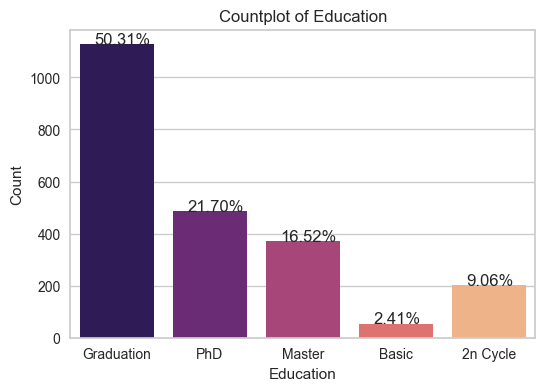

In [14]:
plot_univariate_distribution(data, column="Education", plot_type="countplot")

---
<a name = Section2></a>
#### Insights:

- Education Qualification of customer
- More than 50% customer is graduate
- Approx 22% customer is having PhD degree
- Approx 17% customer is having Master's degree

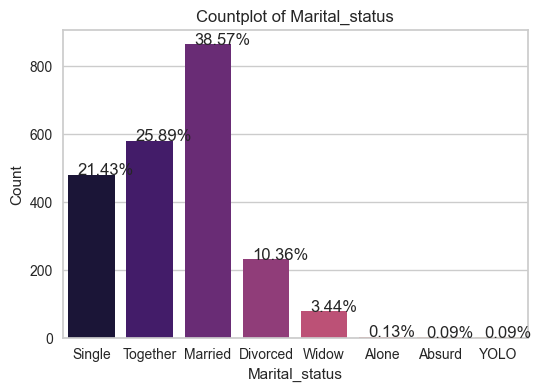

In [15]:
plot_univariate_distribution(data, column="Marital_Status", plot_type="countplot")

---
<a name = Section2></a>
#### Insights:

- Marital Status of customer
- Approx 26% customer are living together
- Approx 39% customer are married
- Approx 10% customer are divorced
- Approx 3% customer are widow
- Approx 21% customer are single and 0.13% customer are alone. We can combine this 2 categories to 1. Remaining categories we can drop out or mark as others.

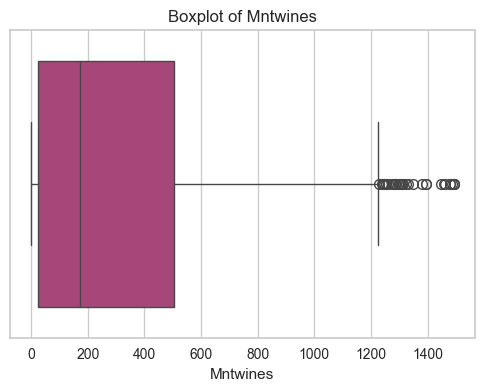

In [16]:
plot_univariate_distribution(data, column="MntWines", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- Amount spent on wine
- 50% customers spend less than 154.00 on wine
- 75% customers spend less that 505.00 on wine
- Also we can see that there are customers who spend a lot on wine, which is visible as the extended right whisher and outliers.

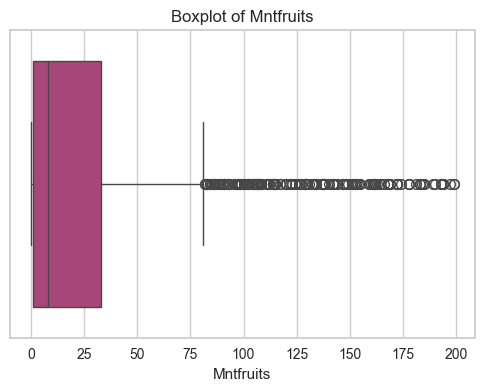

In [17]:
plot_univariate_distribution(data, column="MntFruits", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- Amount spent on fruits
- 50% customers has spend below 8.00
- 75% customer has spend below 33.00
- However ther are customers we has relatively high spending on fruits which is represented by extended right whiskers and outliers.

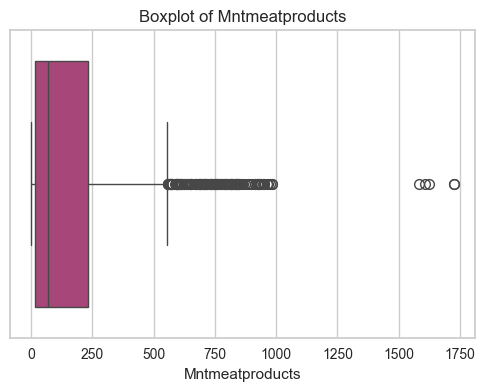

In [18]:
plot_univariate_distribution(data, column="MntMeatProducts", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- Amount spent on meat products
- 50% customers has spend less than 67.00
- 75% customers has spend less than 232.00
- However ther are customers we has relatively high spending on meat products which is represented by extended right whiskers and outliers.

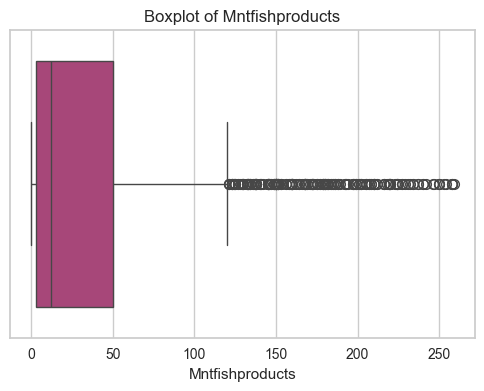

In [19]:
plot_univariate_distribution(data, column="MntFishProducts", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- Amount spent on fish products
- 50% customers has spend less than 12.00
- 75% customers has spend less than 50.00
- However ther are customers we has relatively high spending on fish products which is represented by extended right whiskers and outliers.

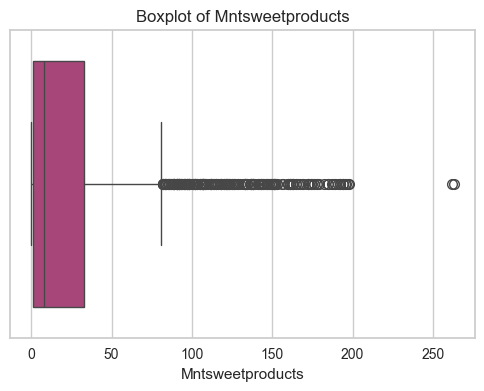

In [20]:
plot_univariate_distribution(data, column="MntSweetProducts", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- Amount spent on sweet products
- 50% customers has spend less than 8.00
- 75% customers has spend less than 33.00
- However ther are customers we has relatively high spending on sweet products which is represented by extended right whiskers and outliers.

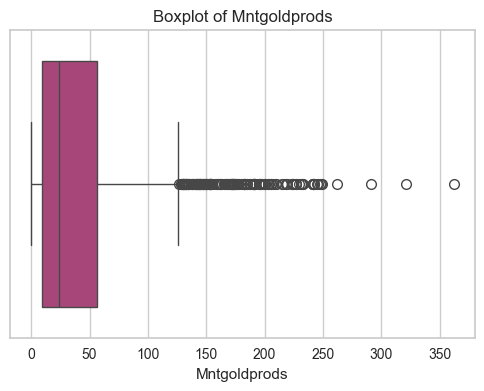

In [21]:
plot_univariate_distribution(data, column="MntGoldProds", plot_type="boxplot")

---
<a name = Section2></a>
#### Insights:

- Amount spent on gold products
- 50% customers has spend less than 24.00
- 75% customers has spend less than 56.00
- However ther are customers we has relatively high spending on sweet products which is represented by extended right whiskers and outliers.

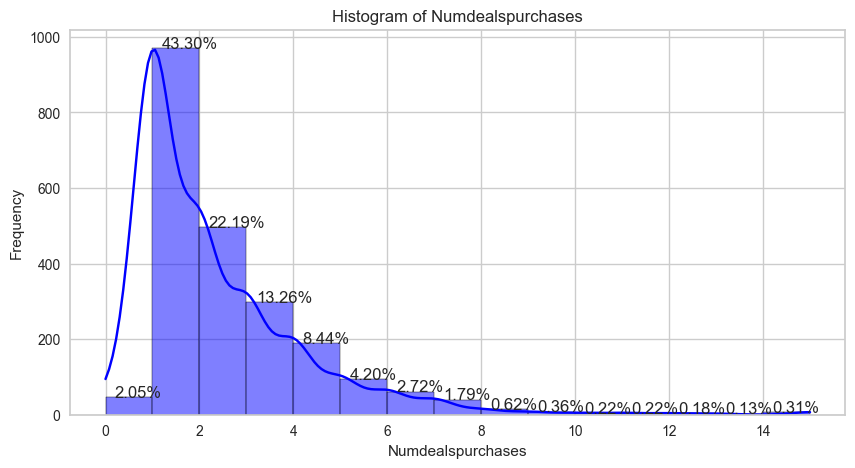

In [22]:
plot_univariate_distribution(data, column="NumDealsPurchases", plot_type="histogram", plot_width=10, plot_height=5, bins=15)

---
<a name = Section2></a>
#### Insights:

- Number of purchases made with a discount
- Appox 50% customers have made <= 2 purchases with a discount
- Appox 75% customers have made <= 3 purchases with a discount
- However, there are customers who has made upto 15 purchases with a discount. 

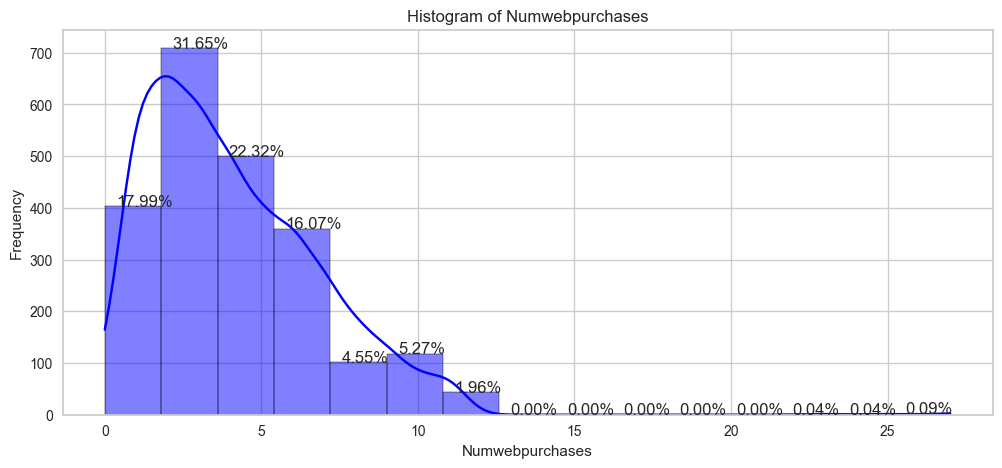

In [23]:
plot_univariate_distribution(data, column="NumWebPurchases", plot_type="histogram", plot_width=12, plot_height=5, bins=15)

---
<a name = Section2></a>
#### Insights:

- Number of purchases made through the company’s web site
- Appox 50% customers have made <= 4 purchases through the company’s web site
- Appox 75% customers have made <= 6 purchases through the company’s web site
- However, there are customers who has made upto 27 purchases through the company’s web site

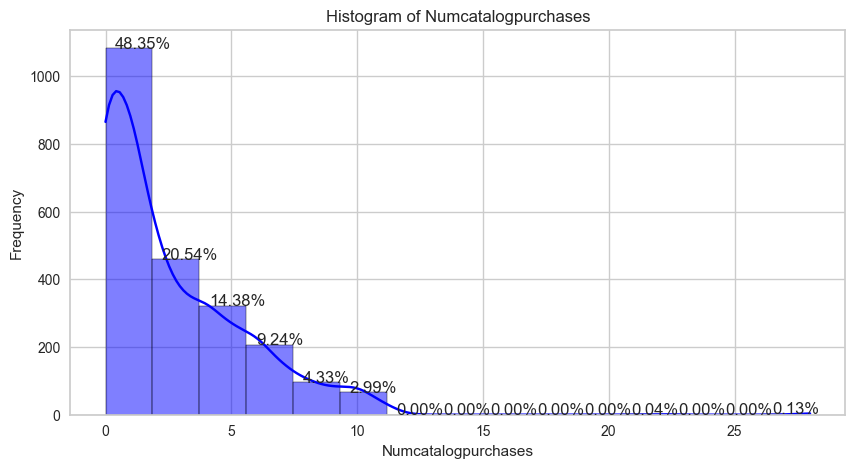

In [24]:
plot_univariate_distribution(data, column="NumCatalogPurchases", plot_type="histogram", plot_width=10, plot_height=5, bins=15)

---
<a name = Section2></a>
#### Insights:

- Number of purchases made using a catalogue
- Appox 50% customers have made <= 2 purchases using a catalogue
- Appox 75% customers have made <= 4 purchases using a catalogue
- However, there are customers who has made upto 28 purchases using a catalogue

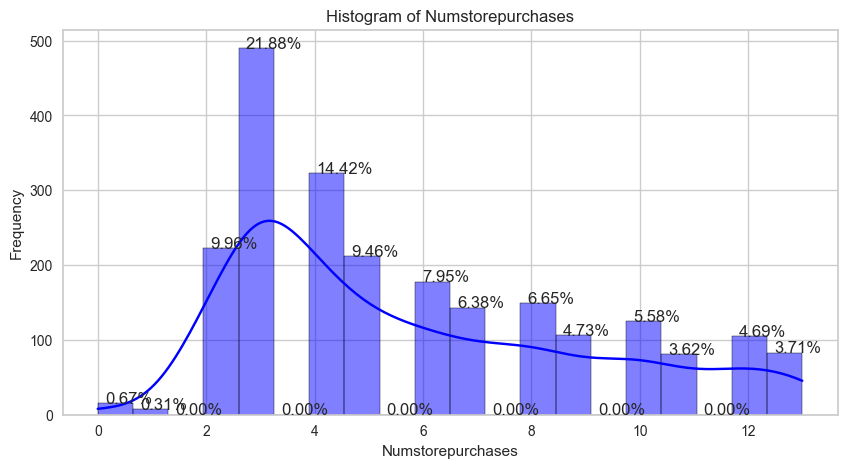

In [25]:
plot_univariate_distribution(data, column="NumStorePurchases", plot_type="histogram", plot_width=10, plot_height=5, bins=20)

---
<a name = Section2></a>
#### Insights:

- Number of purchases made directly in stores
- Appox 50% customers have made <= 5 purchases directly in stores
- Appox 75% customers have made <= 8 purchases directly in stores
- However, there are customers who has made upto 13 purchases directly in stores

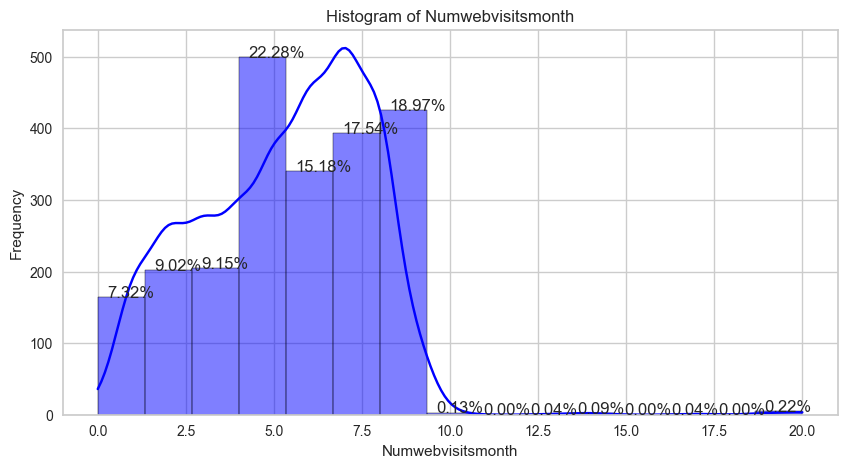

In [26]:
plot_univariate_distribution(data, column="NumWebVisitsMonth", plot_type="histogram", plot_width=10, plot_height=5, bins=15)

---
<a name = Section2></a>
#### Insights:

- Number of visits in the company's website
- Appox 50% customers have made <= 6 visits in the company's website
- Appox 75% customers have made <= 7 visits in the company's website
- However, there are customers who has made upto 20 visits in the company's website

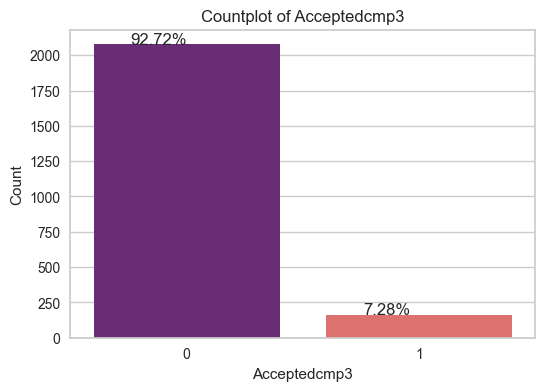

In [27]:
plot_univariate_distribution(data, column="AcceptedCmp3", plot_type="countplot")

---
<a name = Section2></a>
#### Insights:

- 1 if customer accepted the offer in 3rd campaign, otherwise 0
- Approx 93% customers has not accepted offer in 3rd campaign
- Only 7% (approx) customers has accepted offer in 3rd campaign

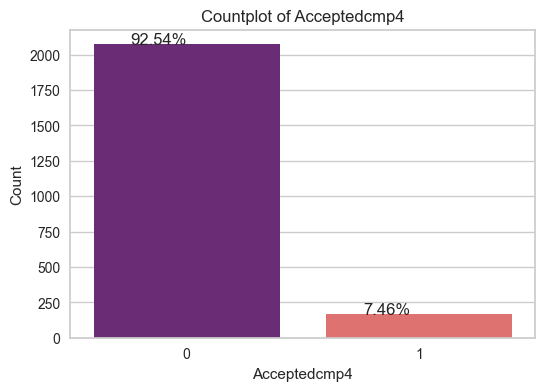

In [28]:
plot_univariate_distribution(data, column="AcceptedCmp4", plot_type="countplot")

---
<a name = Section2></a>
#### Insights:

- 1 if customer accepted the offer in 4th campaign, otherwise 0
- Approx 93% customers has not accepted offer in 4th campaign
- Only 7% (approx) customers has accepted offer in 4th campaign

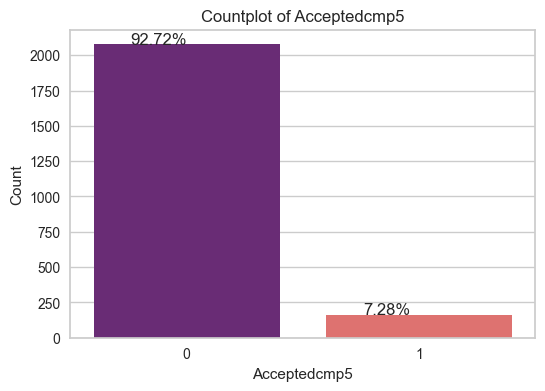

In [29]:
plot_univariate_distribution(data, column="AcceptedCmp5", plot_type="countplot")

---
<a name = Section2></a>
#### Insights:

- 1 if customer accepted the offer in 5th campaign, otherwise 0
- Approx 93% customers has not accepted offer in 5th campaign
- Only 7% (approx) customers has accepted offer in 5th campaign

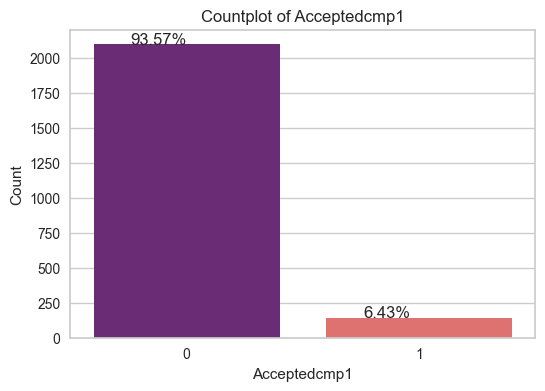

In [30]:
plot_univariate_distribution(data, column="AcceptedCmp1", plot_type="countplot")

---
<a name = Section2></a>
#### Insights:

- 1 if customer accepted the offer in 1st campaign, otherwise 0
- Approx 94% customers has not accepted offer in 1st campaign
- Only 6% (approx) customers has accepted offer in 1st campaign

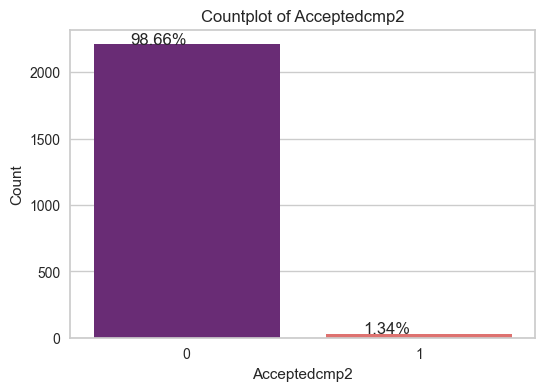

In [31]:
plot_univariate_distribution(data, column="AcceptedCmp2", plot_type="countplot")

---
<a name = Section2></a>
#### Insights:

- 1 if customer accepted the offer in 2nd campaign, otherwise 0
- Approx 99% customers has not accepted offer in 2nd campaign
- Only 1% (approx) customers has accepted offer in 2nd campaign

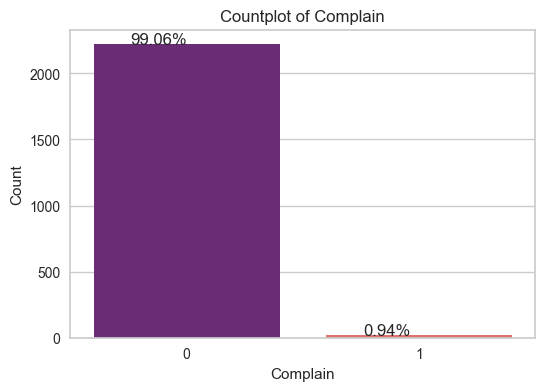

In [32]:
plot_univariate_distribution(data, column="Complain", plot_type="countplot")

---
<a name = Section2></a>
#### Insights:

- 1 if customer complained in last 2 years, else 0
- 99%(approx) customers has not complained in last 2 years

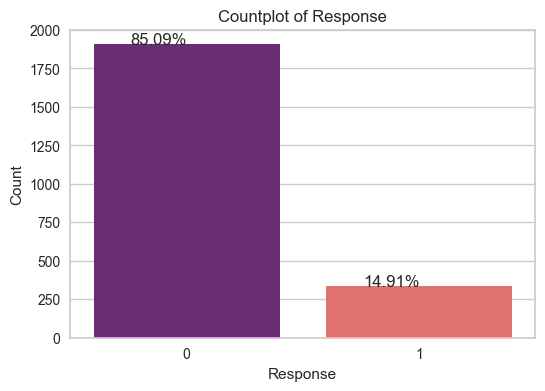

In [33]:
plot_univariate_distribution(data, column="Response", plot_type="countplot")

---
<a name = Section2></a>
#### Insights:

- 1 if customer accepted the offer in the last campaign, otherwise 0
- 85%(approx) customers has not accepted the offer in the last campaign

---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Data Wrangling & Feature Extraction.</u></li>
</ul>
</p>

---


In [34]:
def copy_dataframe(df):
    """
    This function creates and returns a copy of the given DataFrame
    to ensure that the original DataFrame remains unchanged during analysis.
    Also it removes duplicate data points if there are any in the DataFrame.

    Parameters:
    df (pd.DataFrame): The DataFrame to copy.

    Returns:
    pd.DataFrame: A copy of the input DataFrame.
    """
    df_copy = df.copy()

    # dropping duplicate data and keeping the first occurrence of each duplicate
    df_copy.drop_duplicates(inplace=True, keep='first')
    return df_copy

In [35]:
df_copy = copy_dataframe(data.drop(columns=["ID"]))

df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2058 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2058 non-null   int64  
 1   Education            2058 non-null   object 
 2   Marital_Status       2058 non-null   object 
 3   Income               2034 non-null   float64
 4   Kidhome              2058 non-null   int64  
 5   Teenhome             2058 non-null   int64  
 6   Dt_Customer          2058 non-null   object 
 7   Recency              2058 non-null   int64  
 8   MntWines             2058 non-null   int64  
 9   MntFruits            2058 non-null   int64  
 10  MntMeatProducts      2058 non-null   int64  
 11  MntFishProducts      2058 non-null   int64  
 12  MntSweetProducts     2058 non-null   int64  
 13  MntGoldProds         2058 non-null   int64  
 14  NumDealsPurchases    2058 non-null   int64  
 15  NumWebPurchases      2058 non-null   int64 

In [36]:
df_copy.isnull().sum()

Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

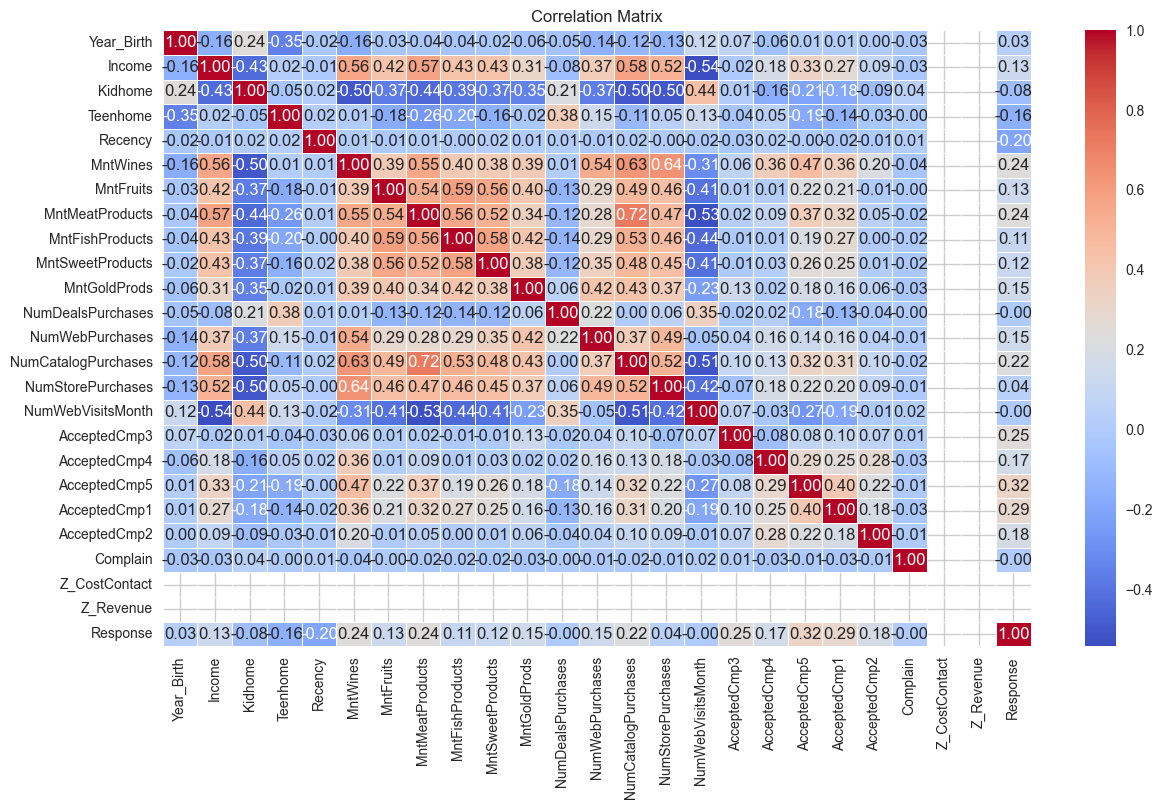

In [37]:
corr_matrix = df_copy.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(14,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [38]:
df_copy["Marital_Status"].value_counts()

Marital_Status
Married     795
Together    521
Single      448
Divorced    216
Widow        71
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [39]:
df_copy["Education"].value_counts()

Education
Graduation    1030
PhD            450
Master         341
2n Cycle       188
Basic           49
Name: count, dtype: int64

In [40]:
def impute_new_features(df):
    """
    This function creates new features in the DataFrame based on existing columns.

    Parameters:
    df (pd.DataFrame): The DataFrame to modify.

    Returns:
    pd.DataFrame: The modified DataFrame with new features.
    """
    current_year = datetime.now().year
    df['Age'] = current_year - df['Year_Birth']
    
    df["Total_Spending"] = df[["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]].sum(axis=1)

    df["Total_Purchases"] = df[["NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]].sum(axis=1)

    df["Children_In_Home"] = df["Kidhome"] + df["Teenhome"]

    df["Campaign_Accepted"] = df[["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5"]].sum(axis=1)


    df["Marital_Status"] = df["Marital_Status"].replace({"Single": "Alone", "Divorced": "Alone", "Widow": "Alone", 
                                                                   "Together": "With_Partner", "Married": "With_Partner", 
                                                                   "Absurd": "Other", "YOLO": "Other"})
    
    df["Education"] = df["Education"].replace({"Basic": "Basic", "2n Cycle": "Basic"})

    #df = pd.get_dummies(df, columns=["Education"], dtype=int, drop_first=True)
    #df = pd.get_dummies(df, columns=["Marital_Status"], dtype=int, drop_first=True)
    
    le = LabelEncoder()
    df["Education_Encoded"]= le.fit_transform(df["Education"])
    df["Marital_Status_Encoded"]= le.fit_transform(df["Marital_Status"])

    df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")

    df["Customer_Since"] = (datetime.now() - df["Dt_Customer"]).dt.days

    df = df.drop(columns=["Dt_Customer", "Year_Birth", "Kidhome", "Teenhome", "NumDealsPurchases", "NumWebPurchases", 
                          "NumCatalogPurchases", "NumStorePurchases", "MntWines", "MntFruits", "MntMeatProducts", 
                          "MntFishProducts", "MntSweetProducts", "MntGoldProds", "AcceptedCmp1", "AcceptedCmp2", 
                          "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Education", "Marital_Status"])
    
    return df

In [41]:
clean_data = impute_new_features(df_copy)
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2058 entries, 0 to 2239
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Income                  2034 non-null   float64
 1   Recency                 2058 non-null   int64  
 2   NumWebVisitsMonth       2058 non-null   int64  
 3   Complain                2058 non-null   int64  
 4   Z_CostContact           2058 non-null   int64  
 5   Z_Revenue               2058 non-null   int64  
 6   Response                2058 non-null   int64  
 7   Age                     2058 non-null   int64  
 8   Total_Spending          2058 non-null   int64  
 9   Total_Purchases         2058 non-null   int64  
 10  Children_In_Home        2058 non-null   int64  
 11  Campaign_Accepted       2058 non-null   int64  
 12  Education_Encoded       2058 non-null   int64  
 13  Marital_Status_Encoded  2058 non-null   int64  
 14  Customer_Since          2058 non-null   int64

In [42]:
clean_data.head(5)

,Income,Recency,NumWebVisitsMonth,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Spending,Total_Purchases,Children_In_Home,Campaign_Accepted,Education_Encoded,Marital_Status_Encoded,Customer_Since
0,58138.00000,58,7,0,3,11,1,69,1617,25,0,0,1,0,5100
1,46344.00000,38,5,0,3,11,0,72,27,6,2,0,1,0,4550
2,71613.00000,26,4,0,3,11,0,61,776,21,0,0,1,2,4749
3,26646.00000,26,6,0,3,11,0,42,53,8,1,0,1,2,4576
4,58293.00000,94,5,0,3,11,0,45,422,19,1,0,3,2,4598


In [43]:
def missing_value_treatment(df):
    """
    This function performs missing value treatment on the DataFrame using the KNN imputation method.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.

    Returns:
    pd.DataFrame: A DataFrame with missing values treated.
    """

    rscaler = RobustScaler()
    scaled_data = rscaler.fit_transform(df)

    scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

    knn_imputer = KNNImputer(n_neighbors=4)
    imputed_data = knn_imputer.fit_transform(scaled_df)
    imputed_df = pd.DataFrame(imputed_data, columns=df.columns)

    original_data = rscaler.inverse_transform(imputed_df)
    original_df = pd.DataFrame(original_data, columns=df.columns)

    return original_df

In [44]:
clean_data = missing_value_treatment(clean_data)
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2058 entries, 0 to 2057
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Income                  2058 non-null   float64
 1   Recency                 2058 non-null   float64
 2   NumWebVisitsMonth       2058 non-null   float64
 3   Complain                2058 non-null   float64
 4   Z_CostContact           2058 non-null   float64
 5   Z_Revenue               2058 non-null   float64
 6   Response                2058 non-null   float64
 7   Age                     2058 non-null   float64
 8   Total_Spending          2058 non-null   float64
 9   Total_Purchases         2058 non-null   float64
 10  Children_In_Home        2058 non-null   float64
 11  Campaign_Accepted       2058 non-null   float64
 12  Education_Encoded       2058 non-null   float64
 13  Marital_Status_Encoded  2058 non-null   float64
 14  Customer_Since          2058 non-null   

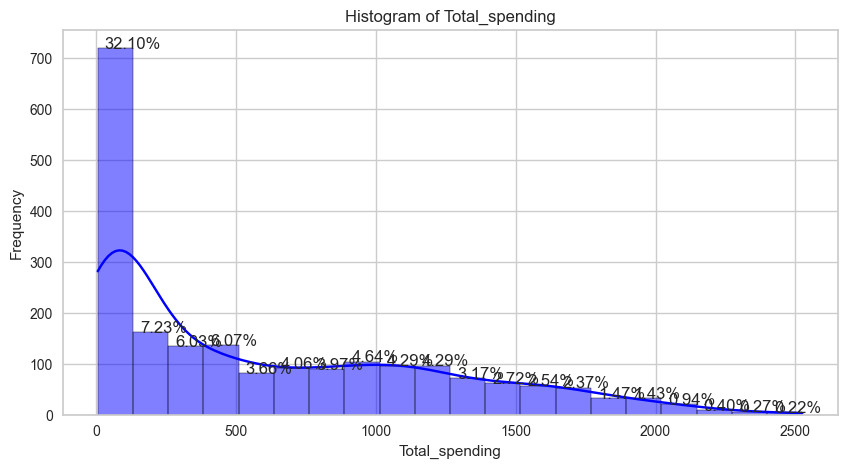

In [45]:
plot_univariate_distribution(clean_data, column="Total_Spending", plot_type="histogram", plot_width=10, plot_height=5, bins=20)

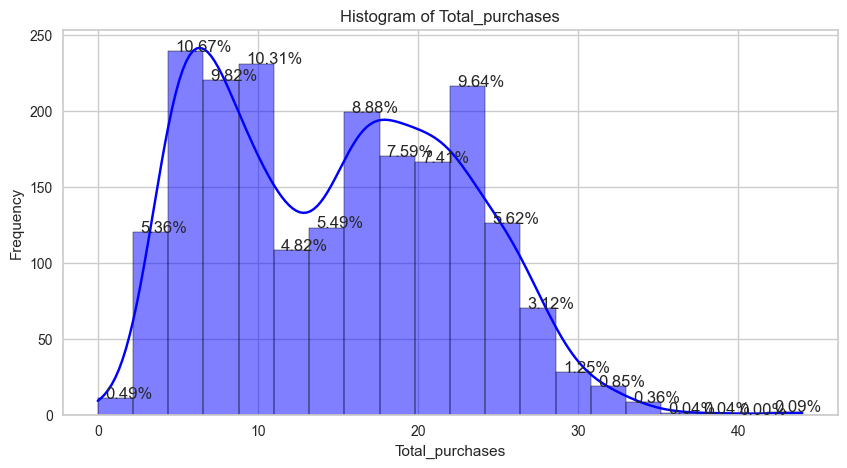

In [46]:
plot_univariate_distribution(clean_data, column="Total_Purchases", plot_type="histogram", plot_width=10, plot_height=5, bins=20)

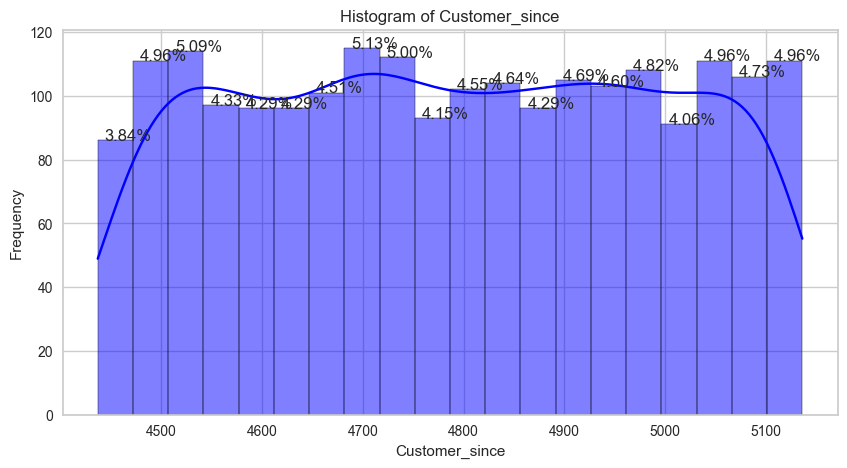

In [47]:
plot_univariate_distribution(clean_data, column="Customer_Since", plot_type="histogram", plot_width=10, plot_height=5, bins=20)

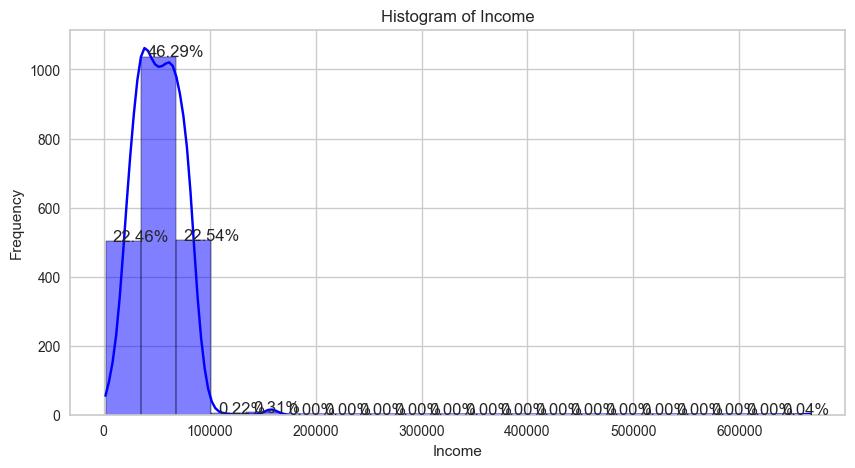

In [48]:
plot_univariate_distribution(clean_data, column="Income", plot_type="histogram", plot_width=10, plot_height=5, bins=20)

In [49]:
def get_bounds_for_outliers(df, column):
    """
    This function calculates the lower and upper bounds for extremeoutliers in a specified column of the DataFrame
    using the 3rd percentile and 97th percentile.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.
    column (str): The name of the column for which to calculate the bounds.

    Returns:
    tuple: A tuple containing the lower bound and upper bound for outliers.
    """
    #Q1 = df[column].quantile(0.25)
    #Q3 = df[column].quantile(0.75)
    #IQR = Q3 - Q1
    #lower_bound = Q1 - 1.5 * IQR
    #upper_bound = Q3 + 1.5 * IQR
    lower_bound = df[column].quantile(0.03)
    upper_bound = df[column].quantile(0.97)

    print(f"For column '{column}':")
    print(f"  Lower Bound: {lower_bound}   Upper Bound: {upper_bound}")
    print("-" * 50)
    return lower_bound, upper_bound

In [50]:
def remove_outliers_old(df, columns):
    """
    This function identifies outliers in the specified columns of the DataFrame and returns a DataFrame 
    by removing the outlier data points and replacing them with their lower bound and upper bound values.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.
    columns (list): A list of column names for which to identify outliers.

    Returns:
    pd.DataFrame: A DataFrame containing the data points without outliers.
    """
    for column in columns:
        lower_bound, upper_bound = get_bounds_for_outliers(df, column)
        # Find outliers
        outliers_low = df[column] < lower_bound
        outliers_high = df[column] > upper_bound

        df.loc[outliers_low, column] = lower_bound
        df.loc[outliers_high, column] = upper_bound
    
    return df

In [51]:
def remove_outliers(df, columns):
    """
    This function identifies outliers in the specified columns of the DataFrame and returns a DataFrame 
    by removing the outlier data points and replacing them with NaN values.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.
    columns (list): A list of column names for which to identify outliers.

    Returns:
    pd.DataFrame: A DataFrame containing the data points without outliers.
    """
    for column in columns:
        lower_bound, upper_bound = get_bounds_for_outliers(df, column)
        # Find outliers
        outliers_low = df[column] < lower_bound
        outliers_high = df[column] > upper_bound

        # Replace outliers with np.nan
        df.loc[outliers_low, column] = np.nan
        df.loc[outliers_high, column] = np.nan
        print(f"Number of outliers in column '{column}': {df[column].isnull().sum()}")
    
    return df

In [52]:
def missing_value_treatment(df):
    """
    This function performs missing value treatment on the DataFrame using the KNN imputation method.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.

    Returns:
    pd.DataFrame: A DataFrame with missing values treated.
    """

    rscaler = RobustScaler()
    scaled_data = rscaler.fit_transform(df)

    scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

    knn_imputer = KNNImputer(n_neighbors=4)
    imputed_data = knn_imputer.fit_transform(scaled_df)
    imputed_df = pd.DataFrame(imputed_data, columns=df.columns)

    original_data = rscaler.inverse_transform(imputed_df)
    original_df = pd.DataFrame(original_data, columns=df.columns)

    return original_df

In [53]:
columns_for_extreme_outliers = ["Income", "Recency", "Total_Spending", "Total_Purchases", "Customer_Since"]
#clean_data = remove_outliers(clean_data, columns_for_extreme_outliers)

In [54]:
clean_data = missing_value_treatment(remove_outliers(clean_data, columns_for_extreme_outliers))
clean_data.info()

For column 'Income':
  Lower Bound: 15963.53   Upper Bound: 88125.12999999999
--------------------------------------------------
Number of outliers in column 'Income': 124
For column 'Recency':
  Lower Bound: 2.0   Upper Bound: 96.0
--------------------------------------------------
Number of outliers in column 'Recency': 104
For column 'Total_Spending':
  Lower Bound: 17.0   Upper Bound: 1921.58
--------------------------------------------------
Number of outliers in column 'Total_Spending': 112
For column 'Total_Purchases':
  Lower Bound: 4.0   Upper Bound: 28.0
--------------------------------------------------
Number of outliers in column 'Total_Purchases': 70
For column 'Customer_Since':
  Lower Bound: 4461.0   Upper Bound: 5116.29
--------------------------------------------------
Number of outliers in column 'Customer_Since': 123
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2058 entries, 0 to 2057
Data columns (total 15 columns):
 #   Column                  Non-Null Count 

In [55]:
def log_transform(df, columns):
    """
    This function applies log transformation to specified columns in the DataFrame.
    Log transformation reduces the influence of extreme values and helps in 
    normalizing the distribution of the data.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.
    columns (list): A list of column names to apply log transformation.

    Returns:
    pd.DataFrame: A DataFrame with log-transformed columns.
    """
    for col in columns:
        df[col] = np.log1p(df[col])  # Using log1p to handle zero values
    return df

In [56]:
# To improve the clustering quality, we can apply log transformation to highly skewed variables 
# such as Income, Total_Spending, and Total_Purchases. These features contain a few extremely 
# large values that may dominate the distance calculation in DBSCAN. By reducing the effect of 
# these outliers, the model can identify more meaningful and stable customer groups.

columns_to_log_transform = ["Income", "Recency", "Total_Spending", "Total_Purchases", "Customer_Since"]
log_transformed_clean_data = log_transform(clean_data, columns_to_log_transform)

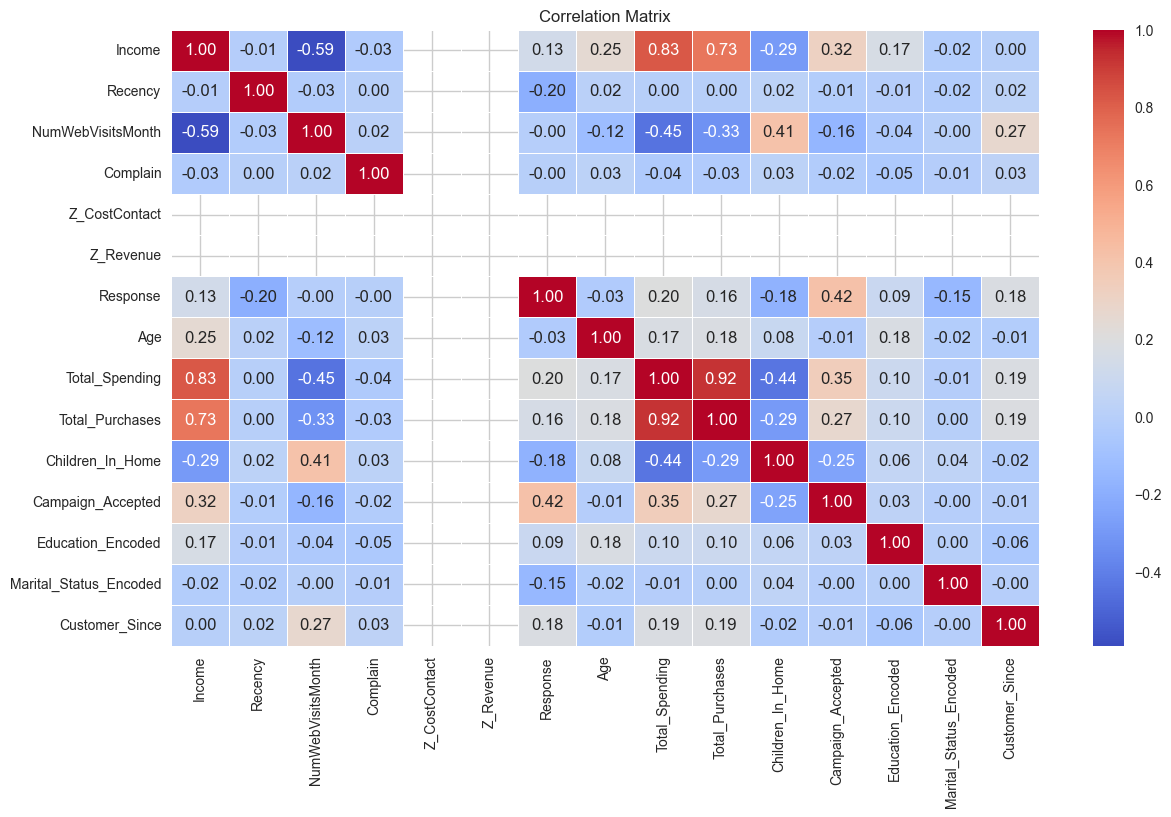

In [57]:
corr_matrix = log_transformed_clean_data.corr()
plt.figure(figsize=(14,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

<h3 style="font-family: 'Segoe UI', Roboto, Arial; font-size:28px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">2. DBSCAN Clustering Parameters:</h3>


---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Scaling.</u></li>
</ul>
</p>

---


In [58]:
def scale_data(df, scaler_type="robust"):
    """
    This function scales the numerical features of the DataFrame using the specified scaler.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.
    scaler_type (str): The type of scaler to use ("robust" or "standard").

    Returns:
    pd.DataFrame: A DataFrame with scaled numerical features.
    """

    if scaler_type == "robust":
        scaler = RobustScaler()
    elif scaler_type == "standard":
        scaler = StandardScaler()
    else:
        raise ValueError("Invalid scaler type. Use 'robust' or 'standard'.")

    scaled_data = scaler.fit_transform(df)
    scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

    return scaled_df

In [59]:
scaled_df = scale_data(log_transformed_clean_data, scaler_type="standard")
scaled_df.shape

(2058, 15)

---

<p style="margin:8px 0 0; color:#334155; font-size:16px;">
<ul>
<li><u>Principal Component Analysis(PCA).</u></li>
</ul>
</p>

---


In [60]:
def perform_pca(data, n_components=None):
    """
    This function performs Principal Component Analysis (PCA) on the given data.

    Parameters:
    data (array-like): The input data to perform PCA on.
    n_components (int or None): The number of principal components to compute. If None, all components are computed.

    Returns:
    tuple: A tuple containing the PCA object and the transformed data.
    """
    pca = PCA(n_components)
    transformed_data = pca.fit_transform(data)
    return pca, transformed_data

In [61]:
# Instead of giving a specific number of principal components, we can specify the amount of variance 
# we want to retain. For example, if we want to retain 90% of the variance, we can set 
# n_components to 0.90. This way, PCA will automatically determine the number of principal components needed 
# to retain that percentage of variance.
#pca = PCA(0.90)
#pca_data = pca.fit_transform(scaled_df)
#pca_data.shape

pca, pca_data = perform_pca(scaled_df, n_components=0.90)
pca_data.shape

(2058, 9)

---
<a name = Section2></a>
#### Insights:

- For retaining 90% variance approx, PCA algorithm was able to achieve it with 9 new features. In other words, from 15 features PCA has successfully brought down it to 9 features with the target of retaining 90% of the variance.

In [62]:
total_variance_explained = sum(pca.explained_variance_ratio_)
print(f"Total variance explained by the selected principal components: {total_variance_explained:.4f}")

Total variance explained by the selected principal components: 0.9118


<h3 style="font-family: 'Segoe UI', Roboto, Arial; font-size:28px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">3. Performing DBSCAN Clustering:</h3>


In [63]:
dbscan = DBSCAN(eps=2, min_samples=3)
dbscan_labels = dbscan.fit_predict(pca_data)

<h3 style="font-family: 'Segoe UI', Roboto, Arial; font-size:28px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">4. Result Analysis:</h3>


In [64]:
silhouette_score_temp = silhouette_score(pca_data, dbscan_labels)

np.unique(dbscan_labels), silhouette_score_temp

(array([-1,  0,  1,  2]), 0.21317650685668324)

In [65]:
100 * np.sum(dbscan_labels == -1) / len(dbscan_labels)

np.float64(2.7696793002915454)

---
<a name = Section2></a>
#### Insights:

- We have executed DBSCAN with params (eps=2, min_samples=3) on pca_data and created dbscan_labels
- From dbscan model labels(dbscan_labels), we have got 4labels, -1 to 2 where -1 = noise and remaining are cluster ids.
    - This means that the model is unable to predict proper clusters with epsilon value of 2 and min samples 3.
    - The same has been confirmed from silhouette score of -0.21(approx). It means the clustering is worse than random grouping and the clusters are not well-separated.
    - Moreover the model has predicted 2.77% data points as outliers.

So from the above we can conclude that :-

- This DBSCAN parameter combination is not appropriate for this transformed dataset.
- Almost all points are treated as noise, so the algorithm is not discovering meaningful clusters.
- We should tune eps and min_samples, reconsider the PCA preprocessing, or try a different clustering approach.

<h3 style="font-family: 'Segoe UI', Roboto, Arial; font-size:28px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">5. Evaluation and Iteration:</h3>


In [66]:
outlier_percent = []

for eps in np.linspace(0.01,5,100):
    for n in range(2, 2*pca_data.shape[1]+1):
        dbscan = DBSCAN(eps=eps, min_samples=n)
        dbscan_labels = dbscan.fit_predict(pca_data)
        outlier_percentage = 100 * np.sum(dbscan_labels == -1) / len(dbscan_labels)
        outlier_percent.append([eps, n, outlier_percentage, len(np.unique(dbscan_labels))])

In [67]:
outlier_percent_df = pd.DataFrame(outlier_percent, columns=["Epsilon", "Min_Samples", "Outlier_Percentage", "Num_Clusters"])
outlier_percent_df.head()

,Epsilon,Min_Samples,Outlier_Percentage,Num_Clusters
0,0.01000,2,99.80564,3
1,0.01000,3,100.00000,1
2,0.01000,4,100.00000,1
3,0.01000,5,100.00000,1
4,0.01000,6,100.00000,1


In [68]:
outlier_percent_df[ outlier_percent_df['Outlier_Percentage'] == outlier_percent_df['Outlier_Percentage'].min() ]

,Epsilon,Min_Samples,Outlier_Percentage,Num_Clusters
1632,4.84879,2,0.04859,3
1633,4.84879,3,0.04859,3
1634,4.84879,4,0.04859,3
1635,4.84879,5,0.04859,3
1636,4.84879,6,0.04859,3
1637,4.84879,7,0.04859,3
1638,4.84879,8,0.04859,3
1639,4.84879,9,0.04859,3
1649,4.89919,2,0.04859,3
1650,4.89919,3,0.04859,3


In [69]:
min_samples = outlier_percent_df[ outlier_percent_df['Outlier_Percentage'] == outlier_percent_df['Outlier_Percentage'].min() ]["Min_Samples"]
np.unique(min_samples)

array([ 2,  3,  4,  5,  6,  7,  8,  9, 10])

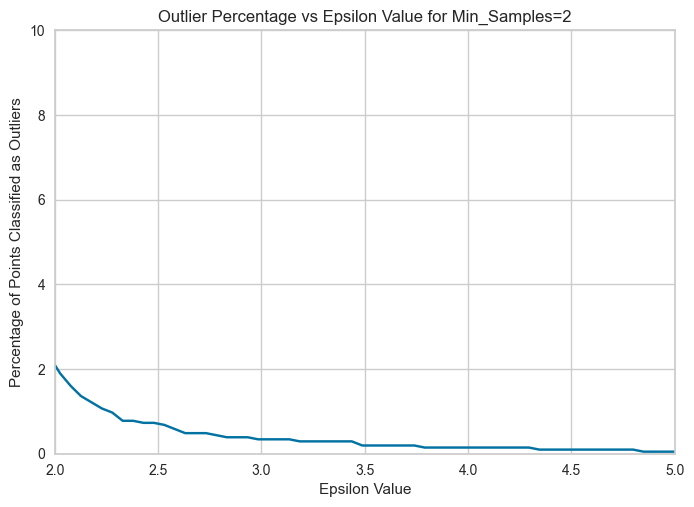

In [70]:
op_df = outlier_percent_df[ outlier_percent_df['Min_Samples'] == 2 ]
sns.lineplot(x=np.linspace(0.01,5,100),y=op_df['Outlier_Percentage'])
plt.xlim(2, 5)
plt.ylim(0, 10)
plt.title("Outlier Percentage vs Epsilon Value for Min_Samples=2")
plt.ylabel("Percentage of Points Classified as Outliers")
plt.xlabel("Epsilon Value")
plt.show()

In [71]:
outlier_percent_df[outlier_percent_df["Min_Samples"]==3]["Outlier_Percentage"].min()

np.float64(0.04859086491739553)

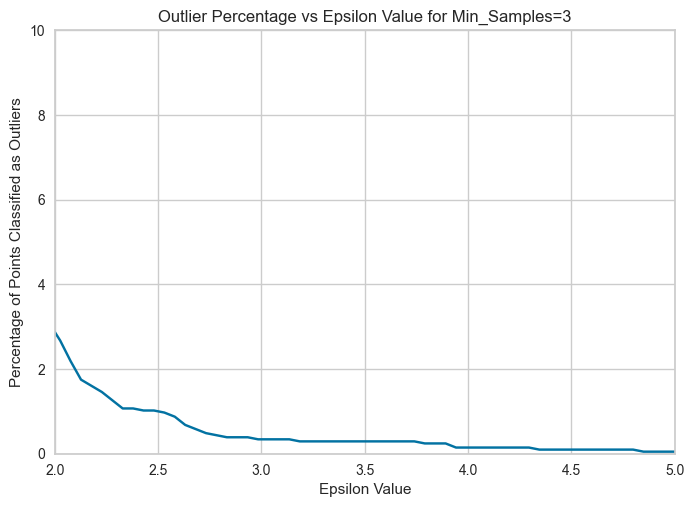

In [72]:
op_df = outlier_percent_df[ outlier_percent_df['Min_Samples'] == 3 ]
sns.lineplot(x=np.linspace(0.01,5,100),y=op_df['Outlier_Percentage'])
plt.xlim(2, 5)
plt.ylim(0, 10)
plt.title("Outlier Percentage vs Epsilon Value for Min_Samples=3")
plt.ylabel("Percentage of Points Classified as Outliers")
plt.xlabel("Epsilon Value")
plt.show()

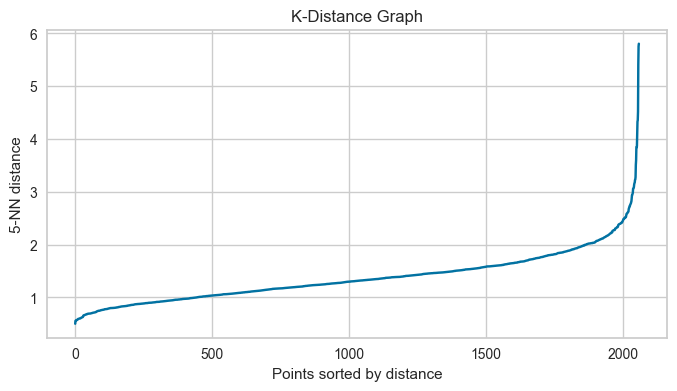

In [73]:
# We can use the K-Distance Graph to determine the optimal value of epsilon for DBSCAN. 
# The idea is to plot the distances of each point to its k-th nearest neighbor 
# (where k is equal to min_samples) and look for a "knee" in the graph. 
# The point at which the graph shows a sharp change in slope indicates a 
# suitable value for epsilon.
nbrs = NearestNeighbors(n_neighbors=5).fit(pca_data)
distances, _ = nbrs.kneighbors(pca_data)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title("K-Distance Graph")
plt.xlabel("Points sorted by distance")
plt.ylabel("5-NN distance")
plt.show()

---
<a name = Section2></a>
#### Insights:

- A k-distance plot can help identify a suitable epsilon value for DBSCAN by showing where the distance curve changes sharply. This approach is often more informative than random parameter selection because it highlights the natural density threshold in the data.
- From all the previous graphs, we can conclude that our epsilon value is in between 3 to 4 approx

In [74]:
result = []
for n in range(2, 2*pca_data.shape[1]+1):
    for eps in np.linspace(3.2,4.5,50):
        dbscan = DBSCAN(eps=eps, min_samples=n)
        dbscan_labels = dbscan.fit_predict(pca_data)

        silhouette_score_new = silhouette_score(pca_data, dbscan_labels)
        result.append([eps, n, silhouette_score_new, 100 * np.sum(dbscan_labels == -1) / len(dbscan_labels), len(np.unique(dbscan_labels))])

result_df = pd.DataFrame(result, columns=["Epsilon", "Min_Samples", "Silhouette_Score", "Outlier_Percentage", "Num_Clusters"])
result_df.head()

,Epsilon,Min_Samples,Silhouette_Score,Outlier_Percentage,Num_Clusters
0,3.20000,2,0.57028,0.29155,3
1,3.22653,2,0.57028,0.29155,3
2,3.25306,2,0.57028,0.29155,3
3,3.27959,2,0.57028,0.29155,3
4,3.30612,2,0.57028,0.29155,3


In [75]:
result_df = result_df.sort_values(by=["Silhouette_Score", "Outlier_Percentage"], ascending=[False, True])


In [76]:
result_df = result_df.where(result_df['Num_Clusters']> 2).sort_values(by=["Silhouette_Score", "Num_Clusters", "Outlier_Percentage"], ascending=[False, False, True])
result_df.head(10)

,Epsilon,Min_Samples,Silhouette_Score,Outlier_Percentage,Num_Clusters
440,4.26122,10.00000,0.59205,0.48591,3.00000
441,4.28776,10.00000,0.59205,0.48591,3.00000
442,4.31429,10.00000,0.59205,0.48591,3.00000
491,4.28776,11.00000,0.59205,0.48591,3.00000
492,4.31429,11.00000,0.59205,0.48591,3.00000
493,4.34082,11.00000,0.59175,0.43732,3.00000
543,4.34082,12.00000,0.59175,0.43732,3.00000
544,4.36735,12.00000,0.59175,0.43732,3.00000
439,4.23469,10.00000,0.59127,0.53450,3.00000
72,3.78367,3.00000,0.59120,0.24295,3.00000


---
<a name = Section2></a>
#### Insights:

- For 2 clusters with Min_Samples 10 we got the highest Silhouette_Score 0.59934 and Outlier_Percentage 1.02041
- For 3 clusters with Min_Samples 10 we got the highest Silhouette_Score 0.59205, however Outlier_Percentage increased to 0.48591


In [77]:
dbscan_2 = DBSCAN(eps=4.0, min_samples=10)
dbscan_labels = dbscan_2.fit_predict(pca_data)
copied_clean_data = log_transformed_clean_data.copy()
copied_clean_data["DBSCAN_Labels"] = dbscan_labels

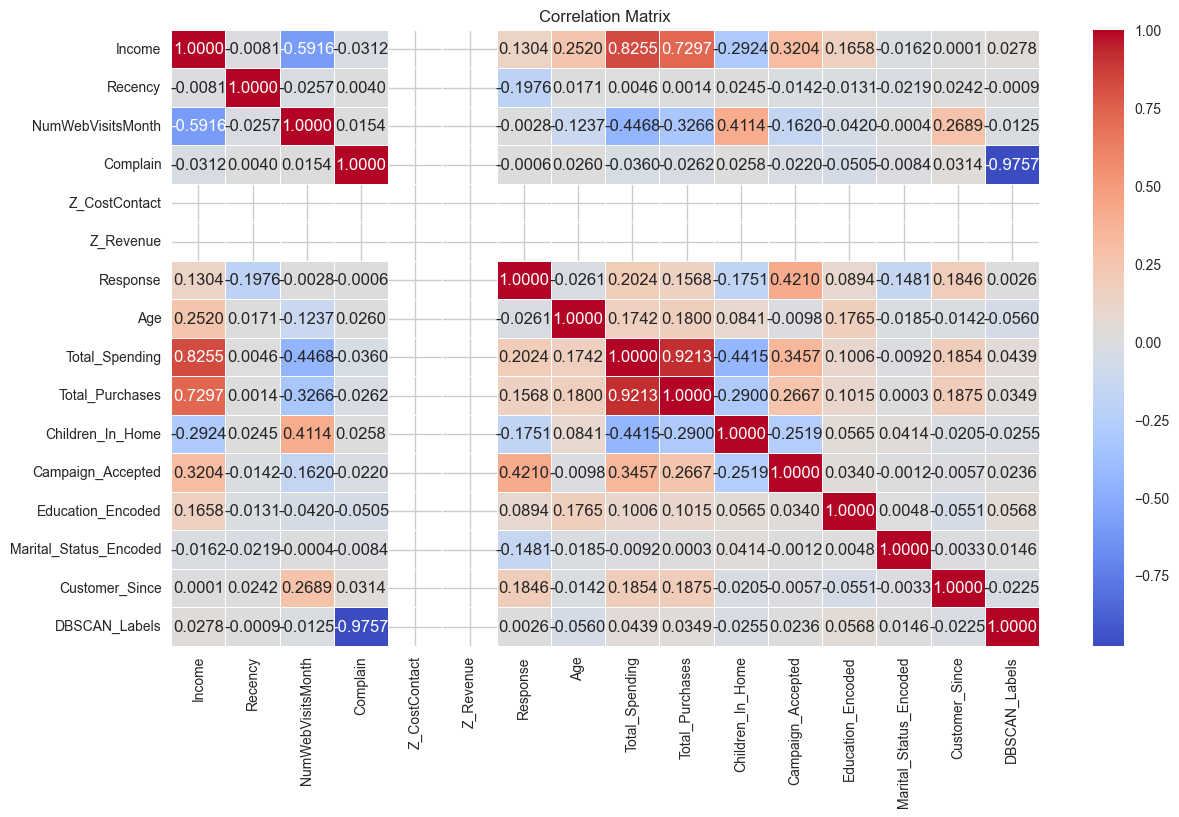

In [78]:
corr_matrix = copied_clean_data.corr()
plt.figure(figsize=(14,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.4f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

---
<a name = Section2></a>
#### Insights:

- Their is no strong predictor for the Labels except 'Complain'
- 'Customer_Since', 'NumWebVisitsMonth', 'Response', 'Marital_Status_Encoded' and 'Recency' are showing the least corelation

In [79]:
log_transformed_clean_data.drop(columns=['Customer_Since', 'NumWebVisitsMonth', 'Response', 'Marital_Status_Encoded', 'Recency'], inplace=True, errors='ignore')
scaled_df = scale_data(log_transformed_clean_data, scaler_type="standard")
scaled_df.shape

(2058, 10)

In [80]:
result = []
for n in range(6, 11):
    for nc in [0.7, 0.75, 0.8, 0.85, 0.9]:
        pca, pca_data = perform_pca(scaled_df, n_components=nc)
        for eps in np.linspace(3.3, 4.2, 20):
            dbscan = DBSCAN(eps=eps, min_samples=n)
            dbscan_labels = dbscan.fit_predict(pca_data)
            outlier_percentage = 100 * np.sum(dbscan_labels == -1) / len(dbscan_labels)
            silhouette_score_new = silhouette_score(pca_data, dbscan_labels)
            result.append((eps, n, nc, pca_data.shape[1], outlier_percentage, silhouette_score_new, len(np.unique(dbscan_labels)), np.unique(dbscan_labels)))

result_df = pd.DataFrame(result, columns=["Epsilon", "Min_Samples", "PCA_Variance_Retained", "Num_PCA_Components", "Outlier_Percentage", "Silhouette_Score", "Num_Clusters", "Cluster_Labels"])
result_df.sort_values(by=["Silhouette_Score"], ascending=False, inplace=True)
result_df.head(10)

,Epsilon,Min_Samples,PCA_Variance_Retained,Num_PCA_Components,Outlier_Percentage,Silhouette_Score,Num_Clusters,Cluster_Labels
432,3.86842,10,0.75000,4,0.00000,0.72504,2,"[0, 1]"
433,3.91579,10,0.75000,4,0.00000,0.72504,2,"[0, 1]"
434,3.96316,10,0.75000,4,0.00000,0.72504,2,"[0, 1]"
435,4.01053,10,0.75000,4,0.00000,0.72504,2,"[0, 1]"
436,4.05789,10,0.75000,4,0.00000,0.72504,2,"[0, 1]"
437,4.10526,10,0.75000,4,0.00000,0.72504,2,"[0, 1]"
438,4.15263,10,0.75000,4,0.00000,0.72504,2,"[0, 1]"
439,4.20000,10,0.75000,4,0.00000,0.72504,2,"[0, 1]"
425,3.53684,10,0.75000,4,0.00000,0.72504,2,"[0, 1]"
426,3.58421,10,0.75000,4,0.00000,0.72504,2,"[0, 1]"


In [81]:
result_df.where(result_df['Num_Clusters']> 2).sort_values(by=["Num_Clusters", "Silhouette_Score", "Outlier_Percentage"], ascending=[False, False, True]).head(10)

,Epsilon,Min_Samples,PCA_Variance_Retained,Num_PCA_Components,Outlier_Percentage,Silhouette_Score,Num_Clusters,Cluster_Labels
403,3.44211,10.00000,0.70000,4.00000,0.04859,0.71869,3.00000,"[-1, 0, 1]"
402,3.39474,10.00000,0.70000,4.00000,0.04859,0.71869,3.00000,"[-1, 0, 1]"
400,3.30000,10.00000,0.70000,4.00000,0.04859,0.71869,3.00000,"[-1, 0, 1]"
404,3.48947,10.00000,0.70000,4.00000,0.04859,0.71869,3.00000,"[-1, 0, 1]"
401,3.34737,10.00000,0.70000,4.00000,0.04859,0.71869,3.00000,"[-1, 0, 1]"
422,3.39474,10.00000,0.75000,4.00000,0.04859,0.71869,3.00000,"[-1, 0, 1]"
423,3.44211,10.00000,0.75000,4.00000,0.04859,0.71869,3.00000,"[-1, 0, 1]"
424,3.48947,10.00000,0.75000,4.00000,0.04859,0.71869,3.00000,"[-1, 0, 1]"
420,3.30000,10.00000,0.75000,4.00000,0.04859,0.71869,3.00000,"[-1, 0, 1]"
421,3.34737,10.00000,0.75000,4.00000,0.04859,0.71869,3.00000,"[-1, 0, 1]"


<h3 style="font-family: 'Segoe UI', Roboto, Arial; font-size:28px; margin:0; background: -webkit-linear-gradient(90deg,#0f172a,#4f46e5); -webkit-background-clip: text; color: transparent;">6. Interpretation and Conclusion:</h3>


---
<a name = Section2></a>
#### Insights:

- Columns:
  - Epsilon: DBSCAN neighborhood radius.
  - Min_Samples: minimum points to form a core point.
  - PCA_Variance_Retained / Num_PCA_Components: PCA configuration used before clustering.
  - Outlier_Percentage: % points labeled noise (-1).
  - Silhouette_Score: clustering quality (higher is better; valid only if >=2 clusters).
  - Num_Clusters: unique labels produced (includes noise if present).
  - Cluster_Labels: what are the generated labels for the cluster.
  
- With Epsilon= 3.34737, Min_Samples= 10, PCA_Variance_Retained= 0.75, Num_PCA_Components= 4, we got Silhouette_Score= 0.71869 with Outlier_Percentage = 0.04859.
- With Epsilon= 3.86842, Min_Samples= 10, PCA_Variance_Retained= 0.75, Num_PCA_Components= 4, we got Silhouette_Score= 0.72504 with Outlier_Percentage = 0. Still now this is the highest Silhouette_Score which we have got for this dataset.



In [82]:
pca, pca_data = perform_pca(scaled_df, n_components=0.75)
cpa_dbscan_model = DBSCAN(eps=3.86842, min_samples=10)
cpa_dbscan_labels = cpa_dbscan_model.fit_predict(pca_data)

In [83]:
df_copy["Labels"] = cpa_dbscan_labels

df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2058 entries, 0 to 2239
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Year_Birth              2058 non-null   int64         
 1   Education               2058 non-null   object        
 2   Marital_Status          2058 non-null   object        
 3   Income                  2034 non-null   float64       
 4   Kidhome                 2058 non-null   int64         
 5   Teenhome                2058 non-null   int64         
 6   Dt_Customer             2058 non-null   datetime64[ns]
 7   Recency                 2058 non-null   int64         
 8   MntWines                2058 non-null   int64         
 9   MntFruits               2058 non-null   int64         
 10  MntMeatProducts         2058 non-null   int64         
 11  MntFishProducts         2058 non-null   int64         
 12  MntSweetProducts        2058 non-null   int64        

In [84]:
df_copy.to_csv('data\\output\\Customer_Personality_Analysis.csv', index=False)

In [85]:
with open('data\\output\\DBSCAN_model.pkl', 'wb') as f:
    pickle.dump(cpa_dbscan_model, f)